# Compositional Generation in Conditional Diffusion Models: The Effect of Factor Correlation on Compositional CFG
topic chosen:Image/Video Generation

In [1]:
import os
os.environ['PYTORCH_CUDA_ALLOC_CONF'] = 'expandable_segments:True'

In [2]:
import os, math, random, json, gc, sys, platform
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path
from tqdm import tqdm
from scipy import linalg  #frechet distance
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
import shutil

In [3]:
print(f'python:{platform.python_version()}')
print(f'torch:{torch.__version__}')
print(f'torch cuda:{torch.version.cuda}')
print(f'cudnn:{torch.backends.cudnn.version()}')
print(f'numpy:{np.__version__}')

python:3.12.13
torch:2.10.0+cu128
torch cuda:12.8
cudnn:91002
numpy:2.0.2


In [4]:
seed=42
random.seed(seed)
np.random.seed(seed)
torch.manual_seed(seed)
torch.cuda.manual_seed_all(seed)
os.environ['PYTHONHASHSEED'] = str(seed)

DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
DETERMINISTIC = True
if DETERMINISTIC:
    torch.backends.cudnn.benchmark = False
    torch.backends.cudnn.deterministic = True
else:
    torch.backends.cudnn.benchmark = True

#checks to make sure gpu is beeing used
print(f'device check: {DEVICE}')
if torch.cuda.is_available():
    print(f'GPU:{torch.cuda.get_device_name(0)}')
    print(f'VRAM:{torch.cuda.get_device_properties(0).total_memory / 1e9:.1f} GB')
print(f'seed={seed}, deterministic={DETERMINISTIC}')


device check: cuda
GPU:Tesla T4
VRAM:15.6 GB
seed=42, deterministic=True


In [5]:
kaggleInput = Path('/kaggle/input')
restored = False

if kaggleInput.exists():
    print('/kaggle/input contents (full recursive listing)')
    _all_input_files = sorted(kaggleInput.rglob('*'))
    if not _all_input_files:
        print('  (empty -- /kaggle/input exists but contains nothing)')
    for p in _all_input_files:
        if p.is_file():
            print(' ', p)
    print('=========================================================')

    _target_subdirs = ['checkpoints', 'data', 'losses', 'figures']
    _target_files = ['sweep_results.json', 'sweep_diagnostics.json', 'run_manifest.json',
                      'ablation_results.json', 'weight_calibration.json',
                      'entanglement_results.json', 'zero_shot_results.json',
                      'sweep_results_seed2.json', 'classifier_test_accuracy.json']

    # recursively find
    for _subdir_name in _target_subdirs:
        for _src_dir in kaggleInput.rglob(_subdir_name):
            if _src_dir.is_dir():
                _dst_dir = Path('/kaggle/working') / _subdir_name
                _dst_dir.mkdir(parents=True, exist_ok=True)
                for _f in _src_dir.iterdir():
                    if _f.is_file() and not (_dst_dir / _f.name).exists():
                        shutil.copy(_f, _dst_dir / _f.name)
                        restored = True
                        print(f'restored {_subdir_name}/{_f.name}  (from {_src_dir})')

    # recursively find and restore named root-level files
    for _fname in _target_files:
        for _src_file in kaggleInput.rglob(_fname):
            if _src_file.is_file():
                _dst_file = Path('/kaggle/working') / _fname
                if not _dst_file.exists():
                    shutil.copy(_src_file, _dst_file)
                    restored = True
                    print(f'restored {_fname}  (from {_src_file})')
                break

    if not restored:
        print('WARNING: /kaggle/input has files but none match')
else:
    print('no /kaggle/input datasets attached -- starting fresh add  previous output as input data')


/kaggle/input contents (full recursive listing)
  /kaggle/input/notebooks/miriamelgawlyuni/newdeeplearningreload/__notebook__.ipynb
  /kaggle/input/notebooks/miriamelgawlyuni/newdeeplearningreload/__output__.json
  /kaggle/input/notebooks/miriamelgawlyuni/newdeeplearningreload/__results__.html
  /kaggle/input/notebooks/miriamelgawlyuni/newdeeplearningreload/__results___files/__results___36_1.png
  /kaggle/input/notebooks/miriamelgawlyuni/newdeeplearningreload/__results___files/__results___40_1.png
  /kaggle/input/notebooks/miriamelgawlyuni/newdeeplearningreload/__results___files/__results___43_1.png
  /kaggle/input/notebooks/miriamelgawlyuni/newdeeplearningreload/__results___files/__results___45_1.png
  /kaggle/input/notebooks/miriamelgawlyuni/newdeeplearningreload/__results___files/__results___65_1.png
  /kaggle/input/notebooks/miriamelgawlyuni/newdeeplearningreload/__results___files/__results___68_0.png
  /kaggle/input/notebooks/miriamelgawlyuni/newdeeplearningreload/__results___file

## Dataset Loading - dSprites

In [6]:
#latents: [color, shape, scale, orientation, posX, posY]
#color is fixed (white--restricting pose/position to simplify task
datasetSpriteURL = 'https://raw.githubusercontent.com/deepmind/dsprites-dataset/master/dsprites_ndarray_co1sh3sc6or40x32y32_64x64.npz'
dataDIR = Path('/kaggle/working/data')
dataDIR.mkdir(parents=True, exist_ok=True)

nShapes= 3
nScaleBins = 3
orient = 4
posFrac = 0.5  # keep middle 50%


def downloadDsprites():
    path = dataDIR / 'dsprites.npz'
    if not path.exists():
        import urllib.request
        print('downloading dsprites')
        urllib.request.urlretrieve(datasetSpriteURL, path)
    return path

def binScale(scale_idx, n_bins=nScaleBins, n_orig=6):
    # maps 6level scale index to  coarse n_bins index
    return np.floor(scale_idx / n_orig * n_bins).astype(int).clip(0, n_bins - 1)
    
def loadDsprites():
    path = downloadDsprites()
    data = np.load(path, allow_pickle=True, encoding='latin1')
    return data['imgs'],data['latents_classes']

In [7]:
def BasePool(imgs,latents_classes):

    shapes=latents_classes[:,1] 
    scales= binScale(latents_classes[:,2])
    orients=latents_classes[:,3]
    posX,posY =latents_classes[:,4],latents_classes[:,5] 

    #middle position window
    n_pos=posX.max()+1
    lo=int(n_pos *(0.5-posFrac/2))
    hi=int(n_pos*(0.5+posFrac/2))
    posMask=(posX >= lo)&(posX<= hi)&(posY >= lo)&(posY<= hi)

    #subsampling orientations uniformly
    n_orient=orients.max()+1
    stride= max(1,n_orient//orient)
    orientMask=(orients%stride==0) 

    mask=posMask&orientMask
    return imgs[mask],shapes[mask],scales[mask]

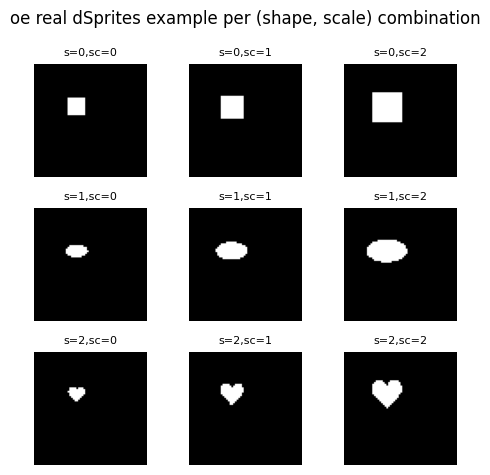

base pool preview size: 20808


In [8]:
#one real example per (shape, scale) combination
imgsPreview, latentsPreview = loadDsprites()
poolPreview, shapePreview, scalePreview = BasePool(imgsPreview, latentsPreview)

figDir = Path('/kaggle/working/figures')
figDir.mkdir(parents=True, exist_ok=True)
fig,axes = plt.subplots(nShapes, nScaleBins,figsize=(nScaleBins*1.6,nShapes*1.6))
for s in range(nShapes):
    for sc in range(nScaleBins):
        idx = np.flatnonzero((shapePreview == s) &(scalePreview == sc))
        ax = axes[s, sc]
        if len(idx) > 0:
            ax.imshow(poolPreview[idx[0]], cmap='gray', vmin=0, vmax=1)
        ax.set_title(f's={s},sc={sc}', fontsize=8)
        ax.axis('off')
plt.suptitle('oe real dSprites example per (shape, scale) combination')
plt.tight_layout()
plt.savefig(figDir/'dataset_samples.png', dpi=120)
plt.show()
print(f'base pool preview size: {len(poolPreview)}')
del imgsPreview,latentsPreview,poolPreview,shapePreview,scalePreview


In [9]:
def correlatedSubset(imgs,shapeLabels,scaleLabels,correlation,nSamples, seed=seed):

    rng = np.random.default_rng(seed) 
    n_perShape= nSamples//nShapes
    pMatch =(1.0 /nScaleBins)+correlation*(1.0-1.0/nScaleBins)

    indices =[]
    for s in range(nShapes):
        matchTrgt= s%nScaleBins
        mask= (shapeLabels==s)

        matchPool=np.flatnonzero(mask&(scaleLabels==matchTrgt))
        otherPool=np.flatnonzero(mask&(scaleLabels!= matchTrgt))

        kMatch= min(int(n_perShape*pMatch),len(matchPool))
        kOther=min(n_perShape-kMatch, len(otherPool))

        sampled = np.concatenate([rng.choice(matchPool,kMatch,replace=False),rng.choice(otherPool,kOther,replace=False)]) 
        indices.append(sampled)

    idx = np.concatenate(indices).astype(int)
    rng.shuffle(idx)
    return imgs[idx],shapeLabels[idx],scaleLabels[idx]

def heldOutCombs():
    # (shape, scale) pairs that are rare/absent in a correlated subset
    out = []
    for s in range(nShapes):
        for sc in range(nScaleBins):
            if sc != (s % nScaleBins):
                out.append((s, sc))
    return out

In [10]:
IMG_SIZE=64
BATCH_SIZE=256
NUM_WORKERS=4 

class DSpritesDataset(Dataset):
    def __init__(self,imgs,shapeLabels,scaleLabels):
        self.imgs =imgs 
        self.shapeLabels=shapeLabels
        self.scaleLabels=scaleLabels

    def __len__(self):
        return len(self.imgs)

    def __getitem__(self, idx):
        img=self.imgs[idx].astype(np.float32)*2.0-1.0  #{0,1} -> [-1,1]
        img =torch.from_numpy(img).unsqueeze(0)# (1,64,64)
        return img, int(self.shapeLabels[idx]),int(self.scaleLabels[idx])


## Forward Diffusion Process

DDPM formulation
x_t = sqrt(alphaBar_t) * x0 + sqrt(1 - alphaBar_t) * eps

In [11]:
!pip install -q tqdm --no-deps

In [12]:
#nooise constrains
T=300
betaStart=1e-4
betaEnd=0.02
betas=torch.linspace(betaStart, betaEnd,T).to(DEVICE)
alphas=1.0- betas 
alphaBars= torch.cumprod(alphas, dim=0)
 
sqrtAB =torch.sqrt(alphaBars)#signal coeff
sqrt1mab=torch.sqrt(1.0-alphaBars) # noise coeff


#adding noise to clean images and gradually denoising pure noise to generate images
#frwd
def qSample(x0, t, noise=None):
    
    if noise is None:
        noise = torch.randn_like(x0)
        
    ab=sqrtAB[t].view(-1,1,1,1)
    ab1m=sqrt1mab[t].view(-1,1,1,1)
    return ab *x0+ab1m*noise,noise
 
#reverse - denoising
@torch.no_grad()
def p_sample_step(model_out, x_t,t):
    # one reverse step, from t -> t-1
    beta_t=betas[t].view(-1,1,1,1)
    alpha_t=alphas[t].view(-1,1,1,1)
    alphaBar_t=alphaBars[t].view(-1,1,1,1)
 
    mean=(1/alpha_t.sqrt())*(x_t-(beta_t/(1-alphaBar_t).sqrt()) *model_out)
 
    if (t==0).all():
        return mean
    noise=torch.randn_like(x_t)
    return mean+beta_t.sqrt()*noise

## Model - Conditional U-Net, TWO conditioning branches

In [13]:
class SinusoidalPosEmb(nn.Module):
    def __init__(self, dim):
        super().__init__()
        self.dim =dim
 
    def forward(self, t):
        half=self.dim//  2
        freqs= torch.exp(-math.log(10000) * torch.arange(half, device=t.device)/(half-1))
        args=t[:, None].float() * freqs[None]
        return torch.cat([args.sin(),args.cos()],dim=-1)
        

In [14]:
class ResBlock(nn.Module):
    # residual block with conditioning injection
    def __init__(self, in_ch, out_ch, cond_dim):
        super().__init__()
        self.conv1=nn.Conv2d(in_ch,out_ch,3,padding=1 )
        self.conv2=nn.Conv2d(out_ch,out_ch,3,padding=1)
        self.norm1=nn.GroupNorm(8,out_ch)
        self.norm2=nn.GroupNorm(8, out_ch)
        self.cond_fc=nn.Linear(cond_dim,out_ch)
        self.skip=nn.Conv2d(in_ch,out_ch,1) if in_ch !=out_ch else nn.Identity()
        self.act=nn.SiLU()
 
    def forward(self, x, cond):
        h=self.act( self.norm1(self.conv1(x))  )
        h=h+ self.cond_fc(self.act(cond))[:,:,None,None]
        h=self.act( self.norm2(self.conv2(h)) )
        return h+self.skip(x)
 


In [15]:
class Downsample(nn.Module):
    def __init__(self, ch):
        super().__init__()
        self.c = nn.Conv2d(ch,ch,4,2,1)
 
    def forward(self, x):
        return self.c(x)
 
 
class Upsample(nn.Module):
    def __init__(self, ch):
        super().__init__()
        self.c=nn.ConvTranspose2d(ch,ch,4,2,1)
 
    def forward(self, x):
        return self.c(x)

In [16]:
class ConditionalUNet(nn.Module):
    # u-net denoising backbone, conditioned on timestep,shape,scale
    def __init__(self, in_ch=1, base_ch=96, time_dim=128, nShapes=3, n_scales=3):
        super().__init__()
        self.time_mlp=nn.Sequential(
            SinusoidalPosEmb(time_dim),
            nn.Linear(time_dim, time_dim*2), nn.SiLU(),
            nn.Linear(time_dim*2, time_dim),
        )
        #+1 slot on each embedding table for  null/dropout token
        self.shape_emb=nn.Embedding(nShapes+1,time_dim)
        self.scale_emb=nn.Embedding(n_scales+ 1,time_dim)
        self.nShapes=nShapes
        self.n_scales= n_scales
 
        self.enc1 = ResBlock(in_ch,base_ch,time_dim)# 64x64
        self.down1= Downsample(base_ch)
        self.enc2 =ResBlock(base_ch,base_ch*2,time_dim)# 32x32
        self.down2=Downsample(base_ch*2)
        self.enc3 =ResBlock(base_ch*2,base_ch*4,time_dim)# 16x16
        self.down3= Downsample(base_ch*4)
 
        self.mid1 = ResBlock(base_ch*4,base_ch*4,time_dim)# 8x8 botttleneck
        self.mid2 = ResBlock(base_ch*4,base_ch*4,time_dim)
        
        self.up3 =Upsample(base_ch*4)
        self.dec3= ResBlock(base_ch*8,base_ch*4,time_dim)
        
        self.up2=Upsample(base_ch*4)
        self.dec2 =ResBlock(base_ch*6 ,base_ch*2,time_dim)
        
        self.up1= Upsample(base_ch*2)
        self.dec1= ResBlock(base_ch*3, base_ch , time_dim)
 
        self.out = nn.Sequential(nn.GroupNorm(8, base_ch), nn.SiLU(), nn.Conv2d(base_ch, in_ch, 1))
 
    def forward(self, x, t, shape_lbl, scale_lbl):
        ##use nShapes/n_scales as  null-token index
        cond = self.time_mlp(t) + self.shape_emb(shape_lbl)+self.scale_emb(scale_lbl)
 
        e1= self.enc1(x, cond)
        e2 =self.enc2(self.down1(e1) ,cond)
        e3=self.enc3(self.down2(e2), cond)
 
        b=self.mid1(self.down3(e3), cond)
        b =self.mid2(b, cond)
 
        d3=self.dec3(torch.cat([self.up3(b),e3],1),cond)
        d2=self.dec2(torch.cat([self.up2(d3),e2],1),cond)
        d1=self.dec1(torch.cat([self.up1(d2), e1],1),cond)
 
        return self.out(d1)

In [17]:
def build_condLabels(shape_lbl, scale_lbl, nShapes=nShapes, n_scales=nScaleBins):
    # converts -1 sentinels (dropped / null factor) into the reserved null-token index
    shape_lbl=shape_lbl.clone()
    scale_lbl =scale_lbl.clone()
    shape_lbl[shape_lbl< 0] = nShapes
    scale_lbl[scale_lbl<0] = n_scales
    return shape_lbl, scale_lbl
 
 
## quick check
_model_check = ConditionalUNet().to(DEVICE)
_x=torch.randn(4,1,64, 64).to(DEVICE)
_t =torch.randint(0,T,(4,)).to(DEVICE)
_s, _sc = build_condLabels(torch.tensor([0,1,2,-1]).to(DEVICE), torch.tensor([1,-1,0,2]).to(DEVICE))
assert _model_check(_x,_t,_s,_sc).shape == (4,1,64,64)
print('model shape ok')
del _model_check,_x,_t,_s,_sc


model shape ok


## Training loop with independent per-factor dropout

In [18]:
EPOCHS=100
LR=2e-4
FACTOR_DROPOUT=0.2
CKPT_DIR = Path('/kaggle/working/checkpoints')
CKPT_DIR.mkdir(exist_ok=True)

def ApplyFactorDrpout(labels, prob):
    labels =labels.clone()
    dropMask=torch.rand(labels.shape[0],device=labels.device)<prob
    labels[dropMask]= -1
    return labels

def workerInit(worker_id):
    workerSeed = (seed + worker_id) % (2**32)
    np.random.seed(workerSeed)
    random.seed(workerSeed)

def trainModel(imgs, shapeLabels, scaleLabels, correlation, epochs=EPOCHS):
    dataset = DSpritesDataset(imgs, shapeLabels, scaleLabels)
    loaderGen = torch.Generator().manual_seed(seed)  #shuffle order
    loader = DataLoader(dataset, batch_size=BATCH_SIZE,shuffle=True,num_workers=NUM_WORKERS, drop_last=True,pin_memory=True, persistent_workers=False,worker_init_fn=workerInit, generator=loaderGen)
    model= ConditionalUNet().to(DEVICE)
    optimizer=torch.optim.AdamW(model.parameters(), lr=LR,weight_decay=1e-4)
    scheduler=torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=epochs)
    scaler = torch.amp.GradScaler('cuda')
    losses = []

    
    for epoch in range(epochs):
        
        epoch_loss=0.0
        for img, shape_lbl, scale_lbl in tqdm(loader, desc=f'corr={correlation} epoch {epoch+1}/{epochs}', leave=False):
            img = img.to(DEVICE, non_blocking=True)
            shape_lbl= shape_lbl.to(DEVICE, non_blocking=True)
            scale_lbl=scale_lbl.to(DEVICE, non_blocking=True)

            shape_drop = ApplyFactorDrpout(shape_lbl, FACTOR_DROPOUT)
            scale_drop = ApplyFactorDrpout(scale_lbl, FACTOR_DROPOUT)
            shape_in, scale_in = build_condLabels(shape_drop, scale_drop)

            t = torch.randint(0,T,(img.shape[0],), device=DEVICE)
            x_t, noise = qSample(img,t)

            optimizer.zero_grad(set_to_none=True)
            with torch.autocast(device_type='cuda', dtype=torch.float16):
                pred = model(x_t, t, shape_in, scale_in)
                loss = F.mse_loss(pred, noise)

            scaler.scale(loss).backward()
            scaler.unscale_(optimizer)
            torch.nn.utils.clip_grad_norm_(model.parameters(),1.0)
            scaler.step(optimizer)
            scaler.update()

            epoch_loss += loss.item()

        scheduler.step()
        avg_loss = epoch_loss / len(loader)
        losses.append(avg_loss)
        if (epoch+1)% 10 ==0 or epoch == 0:
            print(f'corr={correlation} epoch {epoch+1}/{epochs}-loss: {avg_loss:.4f}')

    torch.save(model.state_dict(), CKPT_DIR / f'model_corr{correlation}.pt')
    del optimizer, scheduler, scaler
    torch.cuda.empty_cache()
    return model, losses


## Fast batched DDIM sampling

In [19]:
DDIM_STEPS=50
SAMPLE_CHUNK=200
def ddimSchedule(n_steps, T=T):
    #evenly spaced timesteps, descending, ending at 0
    idx = np.linspace(0, T - 1, n_steps).round().astype(int)
    idx = np.unique(idx)[::-1]
    if idx[-1] != 0:
        idx = np.append(idx, 0)
    return idx
    
@torch.no_grad()
def ddimStep(eps, x_t, t_cur, t_prev):
    ab_cur = alphaBars[t_cur].view(-1, 1, 1, 1)
    if (t_prev >= 0).all():
        ab_prev = alphaBars[t_prev].view(-1, 1, 1, 1)
    else:
        ab_prev = torch.ones_like(ab_cur)
    
    #predf x0
    x0_pred = (x_t - torch.sqrt(1 - ab_cur) * eps)/torch.sqrt(ab_cur)
    x0_pred = x0_pred.clamp(-1, 1)
    
    # Direction pointing to x_t
    dir_xt = torch.sqrt(1-ab_prev)* eps
    
    return torch.sqrt(ab_prev)* x0_pred+dir_xt

@torch.no_grad

def ddimJointSampleBatched(model, shape_lbl, scale_lbl, n_steps=DDIM_STEPS, chunk=SAMPLE_CHUNK, init_noise=None):
    N = shape_lbl.shape[0]
    schedule = ddimSchedule(n_steps)
    out = torch.empty(N, 1, IMG_SIZE, IMG_SIZE, device=DEVICE)
    
    n_chunks = (N + chunk - 1) // chunk
    for start in tqdm(range(0, N, chunk), total=n_chunks, desc='DDIM joint sampling', leave=False):
        end = min(start + chunk, N)
        s_lbl, sc_lbl = shape_lbl[start:end], scale_lbl[start:end]
        n = end - start
        x = init_noise[start:end].clone() if init_noise is not None else torch.randn(n, 1, IMG_SIZE, IMG_SIZE, device=DEVICE)
        
        for i, t_val in enumerate(schedule):
            t_prev_val = int(schedule[i + 1]) if i + 1 < len(schedule) else -1
            t = torch.full((n,), int(t_val), dtype=torch.long, device=DEVICE)
            t_prev = torch.full((n,), t_prev_val, dtype=torch.long, device=DEVICE)
            with torch.autocast(device_type='cuda', dtype=torch.float16):
                eps = model(x, t, s_lbl, sc_lbl)
            x = ddimStep(eps.float(), x, t, t_prev)

        out[start:end] = x
    return out

@torch.no_grad()
def ddimComposedSampleBatched(model, shape_lbl, scale_lbl,n_steps=DDIM_STEPS,w_shape=1.0, w_scale=1.0, chunk=SAMPLE_CHUNK):
    N = shape_lbl.shape[0]
    schedule = ddimSchedule(n_steps)
    out = torch.empty(N,1,IMG_SIZE, IMG_SIZE, device=DEVICE)

    n_chunks = (N + chunk - 1) // chunk
    for start in tqdm(range(0, N, chunk), total=n_chunks, desc='DDIM composed sampling', leave=False):
        end = min(start + chunk, N)
        s_lbl, sc_lbl = shape_lbl[start:end], scale_lbl[start:end]
        n = end - start

        null_s = torch.full((n,), nShapes, dtype=torch.long, device=DEVICE)
        null_sc = torch.full((n,), nScaleBins, dtype=torch.long, device=DEVICE)
        shape_batch = torch.cat([null_s, s_lbl, null_s], dim=0)
        scale_batch = torch.cat([null_sc, null_sc, sc_lbl], dim=0)

        x = torch.randn(n, 1, IMG_SIZE, IMG_SIZE, device=DEVICE)

        for i, t_val in enumerate(schedule):
            t_prev_val = int(schedule[i + 1]) if i + 1 < len(schedule) else -1
            x3 = x.repeat(3, 1, 1, 1)
            t3 = torch.full((3 * n,), int(t_val), dtype=torch.long, device=DEVICE)
            with torch.autocast(device_type='cuda', dtype=torch.float16):
                eps3 = model(x3, t3, shape_batch, scale_batch)
            eps3 = eps3.float()
            eps_null, eps_shape, eps_scale = eps3[:n], eps3[n:2*n], eps3[2*n:3*n]
            eps_compose = eps_null + w_shape * (eps_shape - eps_null) + w_scale * (eps_scale - eps_null)

            t = torch.full((n,), int(t_val), dtype=torch.long, device=DEVICE)
            t_prev = torch.full((n,), t_prev_val, dtype=torch.long, device=DEVICE)
            x = ddimStep(eps_compose, x, t, t_prev)

        out[start:end] = x
    return out


def classifierGuidedComposedSample(model, clf, shape_lbl, scale_lbl, n_steps=DDIM_STEPS,guidance_scale=0.5, guidance_frac=0.3, chunk=64):
    N = shape_lbl.shape[0]
    schedule = ddimSchedule(n_steps)
    n_guided_steps = int(len(schedule) * guidance_frac)
    out = torch.empty(N, 1, IMG_SIZE, IMG_SIZE, device=DEVICE)

    for start in range(0, N, chunk):
        end = min(start + chunk, N)
        s_lbl, sc_lbl = shape_lbl[start:end], scale_lbl[start:end]
        n = end - start
        x = torch.randn(n, 1, IMG_SIZE, IMG_SIZE, device=DEVICE)
        null_s = torch.full((n,), nShapes, dtype=torch.long, device=DEVICE)
        null_sc = torch.full((n,), nScaleBins, dtype=torch.long, device=DEVICE)
        shape_batch = torch.cat([null_s, s_lbl, null_s])
        scale_batch = torch.cat([null_sc, null_sc, sc_lbl])

        for i, t_val in enumerate(schedule):
            t_prev_val = int(schedule[i+1]) if i+1 < len(schedule) else -1

            with torch.no_grad():
                x3 = x.repeat(3,1,1,1)
                t3 = torch.full((3*n,), int(t_val), dtype=torch.long, device=DEVICE)
                with torch.autocast(device_type='cuda', dtype=torch.float16):
                    eps3 = model(x3, t3, shape_batch, scale_batch)
                eps3 = eps3.float()
                eps_null, eps_shape, eps_scale = eps3[:n], eps3[n:2*n], eps3[2*n:3*n]
                eps_compose = eps_null + (eps_shape - eps_null) + (eps_scale - eps_null)

            if i >= len(schedule) - n_guided_steps:
                with torch.enable_grad():
                    x_req = x.detach().clone().requires_grad_(True)
                    shape_logits, scale_logits = clf(x_req)
                    logp = F.log_softmax(shape_logits, dim=1)[range(n), s_lbl] + \
                           F.log_softmax(scale_logits, dim=1)[range(n), sc_lbl]
                    grad = torch.autograd.grad(logp.sum(), x_req)[0]
                with torch.no_grad():
                    ab_cur = alphaBars[int(t_val)]
                    eps_guided = eps_compose - guidance_scale * torch.sqrt(1 - ab_cur) * grad
                del x_req, logp, shape_logits, scale_logits, grad
            else:
                eps_guided = eps_compose

            with torch.no_grad():
                t = torch.full((n,), int(t_val), dtype=torch.long, device=DEVICE)
                t_prev = torch.full((n,), t_prev_val, dtype=torch.long, device=DEVICE)
                x = ddimStep(eps_guided, x, t, t_prev).detach()

            del x3, eps3, eps_compose, eps_guided

        out[start:end] = x.detach()
        del x
        torch.cuda.empty_cache()
    return out

## Factor-recovery classifier

In [20]:
#small CNN trained on real images to predict shape+scale
class FactorClassifier(nn.Module):
    def __init__(self, nShapes=nShapes, n_scales=nScaleBins):
        super().__init__()
        self.backbone = nn.Sequential(
            nn.Conv2d(1, 32, 3, 2, 1), nn.ReLU(),# 64->32
            nn.Conv2d(32, 64, 3, 2, 1), nn.ReLU(),# 32->16
            nn.Conv2d(64, 128, 3, 2, 1), nn.ReLU(),#16->8
            nn.AdaptiveAvgPool2d(1), nn.Flatten(),
        )
        self.shape_head = nn.Linear(128, nShapes)
        self.scale_head = nn.Linear(128, n_scales)

    def forward(self, x):
        feat = self.backbone(x)
        return self.shape_head(feat), self.scale_head(feat)

def trainClassifier(imgs, shapeLabels, scaleLabels, epochs=20, test_frac=0.15):
    # heldout split so classifier accuracy on real images is validated on data it never trained on
    rng = np.random.default_rng(seed)
    n = len(imgs)
    perm = rng.permutation(n)
    n_test = int(n * test_frac)
    test_idx, train_idx = perm[:n_test], perm[n_test:]

    dataset = DSpritesDataset(imgs[train_idx], shapeLabels[train_idx], scaleLabels[train_idx])
    loader = DataLoader(dataset, batch_size=BATCH_SIZE, shuffle=True, num_workers=NUM_WORKERS)

    test_dataset = DSpritesDataset(imgs[test_idx], shapeLabels[test_idx], scaleLabels[test_idx])
    test_loader = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False, num_workers=0)

    clf = FactorClassifier().to(DEVICE)
    optimizer = torch.optim.Adam(clf.parameters(), lr=1e-3)
    ce = nn.CrossEntropyLoss()

    for epoch in range(epochs):
        clf.train()
        total, correct_shape, correct_scale = 0, 0, 0
        for img, shape_lbl, scale_lbl in loader:
            img, shape_lbl, scale_lbl = img.to(DEVICE), shape_lbl.to(DEVICE), scale_lbl.to(DEVICE)
            shape_pred, scale_pred = clf(img)
            loss = ce(shape_pred, shape_lbl) + ce(scale_pred, scale_lbl)

            optimizer.zero_grad()
            loss.backward()
            optimizer.step()

            total += img.size(0)
            correct_shape += (shape_pred.argmax(1) == shape_lbl).sum().item()
            correct_scale += (scale_pred.argmax(1) == scale_lbl).sum().item()

        print(f'[classifier] epoch {epoch+1}: train shape acc={correct_shape/total:.3f}, train scale acc={correct_scale/total:.3f}')

    # held-out test accuracy
    clf.eval()
    total, correct_shape, correct_scale = 0, 0, 0
    with torch.no_grad():
        for img, shape_lbl, scale_lbl in test_loader:
            img, shape_lbl, scale_lbl = img.to(DEVICE), shape_lbl.to(DEVICE), scale_lbl.to(DEVICE)
            shape_pred, scale_pred = clf(img)
            total += img.size(0)
            correct_shape += (shape_pred.argmax(1) == shape_lbl).sum().item()
            correct_scale += (scale_pred.argmax(1) == scale_lbl).sum().item()
    test_shape_acc = correct_shape / total
    test_scale_acc = correct_scale / total
    print(f'[classifier] HELD-OUT test accuracy: shape={test_shape_acc:.3f}, scale={test_scale_acc:.3f} (n={total})')

    with open('/kaggle/working/classifier_test_accuracy.json', 'w') as f:
        json.dump({'shape_acc': test_shape_acc, 'scale_acc': test_scale_acc, 'n_test': total}, f, indent=2)

    return clf


In [21]:
@torch.no_grad()
def evalGenerated(clf, generated_imgs, target_shape, target_scale):
    clf.eval()
    shape_pred, scale_pred = clf(generated_imgs)
    shape_correct = shape_pred.argmax(1) == target_shape
    scale_correct = scale_pred.argmax(1) == target_scale
    return {
        'shape_acc': shape_correct.float().mean().item(),
        'scale_acc': scale_correct.float().mean().item(),
        'joint_acc': (shape_correct & scale_correct).float().mean().item(),
    }

@torch.no_grad()
def perSampleJointCorrect(clf, generated_imgs, target_shape, target_scale, chunk=1024):
    clf.eval()
    outs = []
    for start in range(0, generated_imgs.shape[0], chunk):
        end = start + chunk
        shape_pred, scale_pred = clf(generated_imgs[start:end])
        shape_correct = shape_pred.argmax(1) == target_shape[start:end]
        scale_correct = scale_pred.argmax(1) == target_scale[start:end]
        outs.append((shape_correct & scale_correct))
    return torch.cat(outs)


## Evaluation diagnostics

In [22]:
def matchingScaleMap():
    return {s: s % nScaleBins for s in range(nShapes)}

def inDistCombinations():
    m= matchingScaleMap()
    return [(s, m[s]) for s in range(nShapes)]

def realImgsforCombo(pool_imgs, shapeLabels, scaleLabels, s_idx, sc_idx, nSamples, rng):
    idx = np.where((shapeLabels == s_idx) & (scaleLabels == sc_idx))[0]
    n = min(nSamples, len(idx))
    chosen = rng.choice(idx, size=n, replace=False)
    imgs = pool_imgs[chosen].astype(np.float32)# {0,1}
    return torch.from_numpy(imgs).unsqueeze(1)*2.0-1.0# -> [-1,1], matches training convention

@torch.no_grad()
def factorFeatures(clf, imgs_pm1, batch_size=256):
    #(N,1,64,64) tensor in [-1,1]
    clf.eval()
    feats = []
    for start in range(0, imgs_pm1.shape[0], batch_size):
        batch = imgs_pm1[start:start + batch_size].to(DEVICE)
        f = clf.backbone(batch)
        feats.append(f.float().cpu())
    return torch.cat(feats).numpy()

def frechet_distance(feat_a, feat_b, eps=1e-6):
    mu_a, mu_b = feat_a.mean(0), feat_b.mean(0)
    sigma_a = np.cov(feat_a, rowvar=False) + eps * np.eye(feat_a.shape[1])
    sigma_b = np.cov(feat_b, rowvar=False) + eps * np.eye(feat_b.shape[1])
    diff = mu_a - mu_b
    covmean, _ = linalg.sqrtm(sigma_a @ sigma_b, disp=False)
    if np.iscomplexobj(covmean):
        covmean = covmean.real
    return float(diff @ diff + np.trace(sigma_a + sigma_b - 2 * covmean))

@torch.no_grad()
def nnMinDist(generated_pm1, train_pm1, chunk=256):
    #L2 distance to closest training image
    gen_flat = generated_pm1.reshape(generated_pm1.shape[0], -1).to(DEVICE)
    train_flat = train_pm1.reshape(train_pm1.shape[0], -1).to(DEVICE)
    min_dists = []
    for start in range(0, gen_flat.shape[0], chunk):
        batch = gen_flat[start:start + chunk]
        d = torch.cdist(batch, train_flat)
        min_dists.append(d.min(dim=1).values.cpu())
    return torch.cat(min_dists).numpy()

## Correlation sweep

In [23]:
MANIFEST_PATH = Path('/kaggle/working/run_manifest.json')
RESULTS_PATH = Path('/kaggle/working/sweep_results.json')
DIAGNOSTICS_PATH = Path('/kaggle/working/sweep_diagnostics.json')
LOSSES_DIR = Path('/kaggle/working/losses')
LOSSES_DIR.mkdir(exist_ok=True)
FIGURES_DIR = Path('/kaggle/working/figures')
FIGURES_DIR.mkdir(exist_ok=True)

def loadManifest():
    if MANIFEST_PATH.exists():
        return json.load(open(MANIFEST_PATH))
    return {
        'classifier_trained': False,
        'sweep_done': [],
        'ablation_done': False,
        'weight_calib_done': [],#
        'entanglement_done': [],
        'zero_shot_done': False,
        'second_seed_done': [],
    }

def save_manifest(m):
    json.dump(m, open(MANIFEST_PATH, 'w'), indent=2)

def load_json_list(path):
    if Path(path).exists():
        return json.load(open(path))
    return []

def append_json_list(path, new_item):
    data = load_json_list(path)
    data.append(new_item)
    json.dump(data, open(path, 'w'), indent=2)
    return data

def ckptPath(tag):
    return CKPT_DIR / f'model_{tag}.pt'

def saveModel(model, tag):
    torch.save(model.state_dict(),ckptPath(tag))

def load_model(tag):
    model = ConditionalUNet().to(DEVICE)
    model.load_state_dict(torch.load(ckptPath(tag), map_location=DEVICE))
    model.eval()
    return model

def modelExists(tag):
    return ckptPath(tag).exists()

def sync_manifest(m):
    m['classifier_trained'] = (CKPT_DIR / 'classifier.pt').exists()

    diag = load_json_list(DIAGNOSTICS_PATH)
    done_corrs = sorted(set(d['correlation'] for d in diag))
    m['sweep_done'] = done_corrs

    m['ablation_done'] = Path('/kaggle/working/ablation_results.json').exists()

    wc_path = Path('/kaggle/working/weight_calibration.json')
    m['weight_calib_done'] = sorted(set(r['correlation'] for r in load_json_list(wc_path)))

    ent_path = Path('/kaggle/working/entanglement_results.json')
    m['entanglement_done'] = sorted(set(r['correlation'] for r in load_json_list(ent_path)))

    m['zero_shot_done'] = Path('/kaggle/working/zero_shot_results.json').exists()

    s2_path = Path('/kaggle/working/sweep_results_seed2.json')
    m['second_seed_done'] = sorted(set(r['correlation'] for r in load_json_list(s2_path)))
   
    gs_path = Path('/kaggle/working/guidance_sweep.json')
    m['guidance_sweep_done'] = sorted(set(r['condition'] for r in load_json_list(gs_path)))
    
    cg_path = Path('/kaggle/working/classifier_guided_results.json')
    m['classifier_guided_done'] = sorted(set(r['condition'] for r in load_json_list(cg_path)))
    
    er_path = Path('/kaggle/working/entanglement_reverse_results.json')
    m['entanglement_reverse_done'] = sorted(set(r['correlation'] for r in load_json_list(er_path)))
    
    gv2_path = Path('/kaggle/working/classifier_guided_v2_results.json')
    m['guided_v2_done'] = sorted(set(r['condition'] for r in load_json_list(gv2_path)))
    save_manifest(m)
    return m

manifest = loadManifest()
manifest = sync_manifest(manifest)
print('resumability state (rebuilt from what is on disk):')
print(json.dumps(manifest, indent=2))


resumability state (rebuilt from what is on disk):
{
  "classifier_trained": true,
  "sweep_done": [
    0.0,
    0.25,
    0.5,
    0.75,
    0.95
  ],
  "ablation_done": true,
  "weight_calib_done": [
    0.0,
    0.25,
    0.5,
    0.75,
    0.95
  ],
  "entanglement_done": [
    0.0,
    0.25,
    0.5,
    0.75,
    0.95
  ],
  "zero_shot_done": true,
  "second_seed_done": [
    0.0,
    0.25,
    0.5,
    0.75,
    0.95
  ],
  "classifier_guided_done": [],
  "entanglement_reverse_done": [],
  "guidance_sweep_done": [],
  "guided_v2_done": []
}


In [24]:
CORRELATIONS = [0.0, 0.25, 0.5, 0.75, 0.95]
N_SAMPLES_PER_CONDITION = 500

def saveQualgrid(model, combos, tag, n_show=6, sampler=ddimJointSampleBatched):
    fig, axes = plt.subplots(len(combos), n_show, figsize=(n_show * 1.3, len(combos) * 1.5))
    for row, (s_idx,sc_idx) in enumerate(combos):
        s_lbl = torch.full((n_show,), s_idx, dtype=torch.long, device=DEVICE)
        sc_lbl = torch.full((n_show,), sc_idx, dtype=torch.long, device=DEVICE)
        imgs_out = sampler(model, s_lbl, sc_lbl)
        for col in range(n_show):
            ax = axes[row, col] if len(combos) > 1 else axes[col]
            ax.imshow(imgs_out[col, 0].cpu().numpy(), cmap='gray', vmin=-1, vmax=1)
            ax.axis('off')
            if col == 0:
                ax.set_ylabel(f'shape={s_idx}\nscale={sc_idx}', rotation=0, labelpad=28, fontsize=8)
                ax.axis('on')
                ax.set_xticks([])
                ax.set_yticks([])
    plt.suptitle(tag)
    plt.tight_layout()
    plt.savefig(FIGURES_DIR/ f'{tag}.png', dpi=120)
    plt.close(fig)
    print(f'saved figure: figures/{tag}.png')

def runCorrelationSweep(n_train_samples=6000, epochs=200, classifier_epochs=10):
    global manifest
    imgs, latents_classes = loadDsprites()
    pool_imgs, shapeLabels, scaleLabels = BasePool(imgs, latents_classes)
    print(f'base pool size: {len(pool_imgs)}')

    clf_path = CKPT_DIR/'classifier.pt'
    if manifest['classifier_trained'] and clf_path.exists():
        print('classifier already trained -- loading checkpoint')
        clf = FactorClassifier().to(DEVICE)
        clf.load_state_dict(torch.load(clf_path, map_location=DEVICE))
        clf.eval()
    else:
        print('training factor-recovery classifier')
        clf = trainClassifier(pool_imgs, shapeLabels, scaleLabels, epochs=classifier_epochs)
        torch.save(clf.state_dict(), clf_path)
        manifest['classifier_trained'] = True
        save_manifest(manifest)

    rng = np.random.default_rng(seed)
    all_results = load_json_list(RESULTS_PATH)
    diagnostics = load_json_list(DIAGNOSTICS_PATH)
    losses_by_correlation = {}
    for f in LOSSES_DIR.glob('losses_corr*.json'):
        corr_val = float(f.stem.replace('losses_corr', ''))
        losses_by_correlation[corr_val] = json.load(open(f))

    for correlation in CORRELATIONS:
        if correlation in manifest['sweep_done']:
            print('\n')
            print('correlation',correlation,'-- already done, skipping')
            continue

        print('\n')
        print('correlation',correlation)
        sub_imgs, sub_shape, sub_scale = correlatedSubset(
            pool_imgs, shapeLabels, scaleLabels, correlation, n_train_samples)

        tag = f'corr{correlation}'
        if modelExists(tag):
            print('checkpoint',tag,'found -- loading instead of retraining')
            model = load_model(tag)
            losses = losses_by_correlation.get(correlation, [])
        else:
            model,losses =trainModel(sub_imgs, sub_shape, sub_scale, correlation, epochs=epochs)
            model.eval()
            saveModel(model, tag)
            json.dump(losses, open(LOSSES_DIR/f'losses_corr{correlation}.json', 'w'))
        losses_by_correlation[correlation] = losses

        id_combos = inDistCombinations()
        id_shape_lbl = torch.cat([torch.full((N_SAMPLES_PER_CONDITION,),s,dtype=torch.long) for s, _ in id_combos]).to(DEVICE)
        id_scale_lbl = torch.cat([torch.full((N_SAMPLES_PER_CONDITION,),sc,dtype=torch.long) for _, sc in id_combos]).to(DEVICE)
        id_imgs = ddimJointSampleBatched(model, id_shape_lbl, id_scale_lbl)
        id_correct = perSampleJointCorrect(clf, id_imgs, id_shape_lbl, id_scale_lbl)
        in_dist_acc = id_correct.float().mean().item()
        print(f'sanity check in-distribution joint_acc = {in_dist_acc:.3f} '
              f'{"(looks trained)" if in_dist_acc > 0.85 else "(LOW -- add more epochs)"}')
        del id_imgs, id_shape_lbl, id_scale_lbl, id_correct

        combos = heldOutCombs()
        shape_lbl_all = torch.cat([torch.full((N_SAMPLES_PER_CONDITION,), s, dtype=torch.long) for s, _ in combos]).to(DEVICE)
        scale_lbl_all = torch.cat([torch.full((N_SAMPLES_PER_CONDITION,), sc, dtype=torch.long) for _, sc in combos]).to(DEVICE)

        joint_imgs_all = ddimJointSampleBatched(model, shape_lbl_all, scale_lbl_all)
        composed_imgs_all = ddimComposedSampleBatched(model, shape_lbl_all, scale_lbl_all)

        joint_correct = perSampleJointCorrect(clf, joint_imgs_all, shape_lbl_all, scale_lbl_all)
        composed_correct = perSampleJointCorrect(clf, composed_imgs_all, shape_lbl_all, scale_lbl_all)

        for combo_i, (s_idx, sc_idx) in enumerate(combos):
            lo = combo_i * N_SAMPLES_PER_CONDITION
            hi = lo + N_SAMPLES_PER_CONDITION
            joint_acc = joint_correct[lo:hi].float().mean().item()
            composed_acc = composed_correct[lo:hi].float().mean().item()
            all_results = append_json_list(RESULTS_PATH, {
                'correlation': correlation, 'shape': s_idx, 'scale': sc_idx,
                'joint_acc': joint_acc, 'composed_acc': composed_acc,
            })
            print(f'(shape={s_idx}, scale={sc_idx}): joint_acc={joint_acc:.3f}, composed_acc={composed_acc:.3f}')


        saveQualgrid(model, combos[:3], f'joint_corr{correlation}', sampler=ddimJointSampleBatched)
        saveQualgrid(model, combos[:3], f'composed_corr{correlation}', sampler=ddimComposedSampleBatched)

        real_imgs_all = torch.cat([realImgsforCombo(pool_imgs, shapeLabels, scaleLabels, s, sc, N_SAMPLES_PER_CONDITION, rng)
            for s, sc in combos]).to(DEVICE)
        real_feats = factorFeatures(clf, real_imgs_all)
        joint_feats = factorFeatures(clf, joint_imgs_all)
        composed_feats = factorFeatures(clf, composed_imgs_all)
        joint_ffd = frechet_distance(real_feats, joint_feats)
        composed_ffd = frechet_distance(real_feats, composed_feats)
        print(f'Frechet Factor Distance joint={joint_ffd:.2f}, composed={composed_ffd:.2f}')

        train_pm1 = torch.from_numpy(sub_imgs.astype(np.float32)).unsqueeze(1) * 2.0 - 1.0
        nn_dists = nnMinDist(composed_imgs_all.cpu(), train_pm1)
        print(f'memorization check mean={nn_dists.mean():.2f}, min={nn_dists.min():.2f}')

        diagnostics = append_json_list(DIAGNOSTICS_PATH, {
            'correlation': correlation,
            'in_distribution_joint_acc': in_dist_acc,
            'joint_ffd': joint_ffd,
            'composed_ffd': composed_ffd,
            'nn_dist_mean': float(nn_dists.mean()),
            'nn_dist_min': float(nn_dists.min()),
            'final_train_loss': losses[-1] if losses else None,
        })

        manifest['sweep_done'].append(correlation)
        save_manifest(manifest)

        del model, joint_imgs_all, composed_imgs_all, joint_correct, composed_correct
        del shape_lbl_all, scale_lbl_all, real_imgs_all, train_pm1
        torch.cuda.empty_cache()
        gc.collect()

    print('\n')
    print('sweep complete -- results in sweep_results.json / sweep_diagnostics.json')
    return all_results, diagnostics, losses_by_correlation


In [25]:
# accuracy correlation curve for joint vs composed sampling
def plot_degradation_curve(all_results):
    corrs = sorted(set(r['correlation'] for r in all_results))
    joint_means = [np.mean([r['joint_acc'] for r in all_results if r['correlation'] == c]) for c in corrs]
    composed_means = [np.mean([r['composed_acc'] for r in all_results if r['correlation'] == c]) for c in corrs]
 
    plt.figure(figsize=(6, 4))
    plt.plot(corrs, joint_means, marker='o', label='joint sampling (ground truth)')
    plt.plot(corrs, composed_means, marker='s', label='composed sampling (AND-composition)')
    plt.xlabel('training correlation strength')
    plt.ylabel('factor-recovery accuracy (held-out combos)')
    plt.title('Compositional CFG degradation vs. correlation')
    plt.legend()
    plt.tight_layout()
    plt.savefig(FIGURES_DIR/'degradation_curve.png', dpi=120)
    plt.show()

base pool size: 20808
classifier already trained -- loading checkpoint


correlation 0.0 -- already done, skipping


correlation 0.25 -- already done, skipping


correlation 0.5 -- already done, skipping


correlation 0.75 -- already done, skipping


correlation 0.95 -- already done, skipping


sweep complete -- results in sweep_results.json / sweep_diagnostics.json


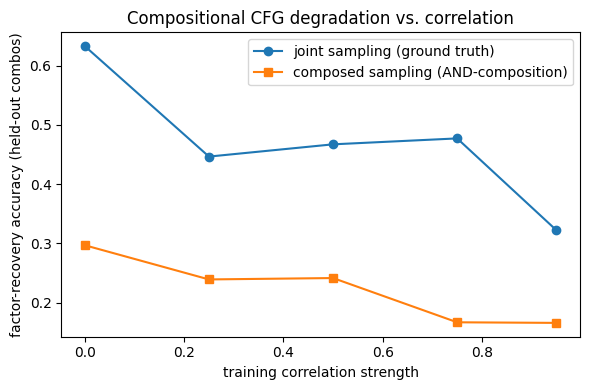

In [26]:
results, diagnostics, losses_by_correlation = runCorrelationSweep(epochs=200)
plot_degradation_curve(results)    

In [27]:
clf = FactorClassifier().to(DEVICE)
clf.load_state_dict(torch.load(CKPT_DIR / 'classifier.pt', map_location=DEVICE))
clf.eval()
print('classifier reloaded')

classifier reloaded


## NoiseAwareFactorClassifier

## Ablation: DDIM sampling steps

ablation already done -- loading saved results


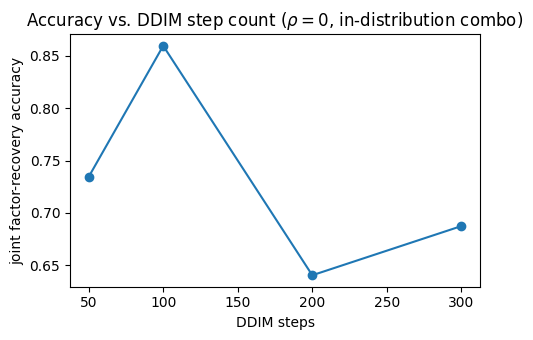

In [28]:
ABLATION_PATH = Path('/kaggle/working/ablation_results.json')

if manifest['ablation_done'] and ABLATION_PATH.exists():
    print('ablation already done -- loading saved results')
    ablation_results = json.load(open(ABLATION_PATH))
else:
    _abl_model = load_model('corr0.0')
    _n_eval = 64
    _s_lbl = torch.full((_n_eval,), 0, dtype=torch.long, device=DEVICE)
    _sc_lbl = torch.full((_n_eval,), 0, dtype=torch.long, device=DEVICE)

    torch.manual_seed(seed)
    _shared_noise = torch.randn(_n_eval, 1, IMG_SIZE, IMG_SIZE, device=DEVICE)

    ablation_results = []
    for steps in [50,100,200,300]:
        imgs_test = ddimJointSampleBatched(_abl_model, _s_lbl, _sc_lbl, n_steps=steps, init_noise=_shared_noise)
        _metrics = evalGenerated(clf, imgs_test, _s_lbl, _sc_lbl)
        ablation_results.append({'steps': steps, **_metrics})
        print(f"DDIM steps={steps}: shape={_metrics['shape_acc']:.3f}, "
              f"scale={_metrics['scale_acc']:.3f}, joint={_metrics['joint_acc']:.3f}")

    json.dump(ablation_results, open(ABLATION_PATH, 'w'), indent=2)
    manifest['ablation_done'] = True
    save_manifest(manifest)
    del _abl_model
    torch.cuda.empty_cache()

# plot
_steps = [r['steps'] for r in ablation_results]
_joint_acc = [r['joint_acc'] for r in ablation_results]
plt.figure(figsize=(5,3.5))
plt.plot(_steps, _joint_acc, marker='o')
plt.xlabel('DDIM steps')
plt.ylabel('joint factor-recovery accuracy')
plt.title('Accuracy vs. DDIM step count ($\\rho=0$, in-distribution combo)')
plt.tight_layout()
plt.savefig(FIGURES_DIR / 'ddim_step_ablation.png', dpi=120)
plt.show()


In [29]:
ABLATION_V2_PATH = Path('/kaggle/working/ablation_v2_results.json')

if not ABLATION_V2_PATH.exists():
    _abl_model = load_model('corr0.0')
    _n_eval = 64
    _s_lbl = torch.full((_n_eval,), 0, dtype=torch.long, device=DEVICE)
    _sc_lbl = torch.full((_n_eval,), 0, dtype=torch.long, device=DEVICE)

    torch.manual_seed(seed)
    _shared_noise = torch.randn(_n_eval, 1, IMG_SIZE, IMG_SIZE, device=DEVICE)

    ablation_v2_results = []
    for steps in [50, 100, 200, 300]:
        imgs_test = ddimJointSampleBatched(_abl_model, _s_lbl, _sc_lbl, n_steps=steps, init_noise=_shared_noise)
        _metrics = evalGenerated(clf, imgs_test, _s_lbl, _sc_lbl)
        ablation_v2_results.append({'steps': steps, **_metrics})
        print(f"[pinned noise] steps={steps}: joint={_metrics['joint_acc']:.3f}")

    json.dump(ablation_v2_results, open(ABLATION_V2_PATH, 'w'), indent=2)
    del _abl_model, _shared_noise
    torch.cuda.empty_cache()
else:
    ablation_v2_results = json.load(open(ABLATION_V2_PATH))
    print('pinned-noise ablation already done, loaded from disk')

[pinned noise] steps=50: joint=0.734


[pinned noise] steps=100: joint=0.688


[pinned noise] steps=200: joint=0.719


[pinned noise] steps=300: joint=0.750


## Contribution: composition-weight calibration

weight calibration corr= 0.0 already done, skipping
weight calibration corr= 0.25 already done, skipping
weight calibration corr= 0.5 already done, skipping
weight calibration corr= 0.75 already done, skipping
weight calibration corr= 0.95 already done, skipping


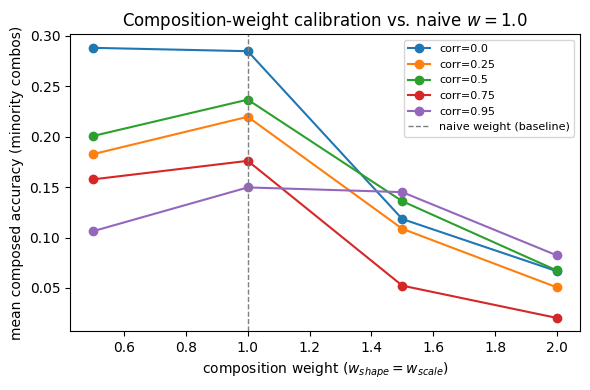

In [30]:
weightCalibrationPth = Path('/kaggle/working/weight_calibration.json')
weightGrid = [0.5,1.0,1.5,2.0]

weightCalibRes =load_json_list(weightCalibrationPth)

for correlation in CORRELATIONS:
    if correlation in manifest['weight_calib_done']:
        print('weight calibration corr=',correlation,'already done, skipping')
        continue

    print('\n')
    print('weight calibration: correlation =' ,correlation)
    model = load_model(f'corr{correlation}')
    combos = heldOutCombs()
    shape_lbl_all = torch.cat([torch.full((N_SAMPLES_PER_CONDITION,), s, dtype=torch.long) for s, _ in combos]).to(DEVICE)
    scale_lbl_all = torch.cat([torch.full((N_SAMPLES_PER_CONDITION,), sc, dtype=torch.long) for _, sc in combos]).to(DEVICE)

    for w in weightGrid:
        imgs_w = ddimComposedSampleBatched(model, shape_lbl_all, scale_lbl_all, w_shape=w, w_scale=w)
        correct_w = perSampleJointCorrect(clf, imgs_w, shape_lbl_all, scale_lbl_all)
        acc_w = correct_w.float().mean().item()
        weightCalibRes = append_json_list(weightCalibrationPth, {'correlation': correlation, 'weight': w, 'composed_acc': acc_w})
        print(f'w_shape=w_scale={w}: composed_acc={acc_w:.3f}')
        del imgs_w, correct_w
        torch.cuda.empty_cache()

    manifest['weight_calib_done'].append(correlation)
    save_manifest(manifest)
    del model, shape_lbl_all, scale_lbl_all
    torch.cuda.empty_cache()
    gc.collect()

#plot: accuracy vs weight, one line per correlation
plt.figure(figsize=(6,4))
for correlation in CORRELATIONS:
    rows = [r for r in weightCalibRes if r['correlation'] == correlation]
    rows = sorted(rows, key=lambda r: r['weight'])
    plt.plot([r['weight'] for r in rows], [r['composed_acc'] for r in rows],
              marker='o', label=f'corr={correlation}')
plt.axvline(1.0, color='gray', linestyle='--', linewidth=1, label='naive weight (baseline)')
plt.xlabel('composition weight ($w_{shape}=w_{scale}$)')
plt.ylabel('mean composed accuracy (minority combos)')
plt.title('Composition-weight calibration vs. naive $w=1.0$')
plt.legend(fontsize=8)
plt.tight_layout()
plt.savefig(FIGURES_DIR / 'weight_calibration.png', dpi=120)
plt.show()


## Contribution: factor-entanglement diagnostic

entanglement corr= 0.0 already done, skipping
entanglement corr= 0.25 already done, skipping
entanglement corr= 0.5 already done, skipping
entanglement corr= 0.75 already done, skipping
entanglement corr= 0.95 already done, skipping


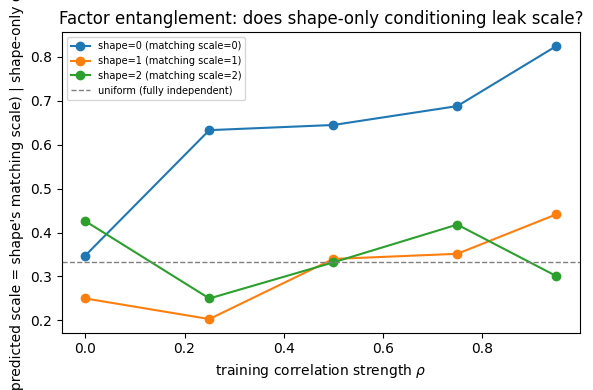

In [31]:
entanglementPath = Path('/kaggle/working/entanglement_results.json')

def measureEntanglement(model, clf, shape_idx, n=256):
    s_lbl = torch.full((n,), shape_idx, dtype=torch.long, device=DEVICE)
    null_sc = torch.full((n,), nScaleBins, dtype=torch.long, device=DEVICE)
    imgs = ddim_joint_sample_batched(model, s_lbl, null_sc)
    with torch.no_grad():
        _, scale_pred = clf(imgs.to(DEVICE))
    counts = torch.bincount(scale_pred.argmax(1).cpu(), minlength=nScaleBins).float()
    return (counts / counts.sum()).tolist()

entanglement_results = load_json_list(entanglementPath)

for correlation in CORRELATIONS:
    if correlation in manifest['entanglement_done']:
        print('entanglement corr=',correlation,'already done, skipping')
        continue
    print('\n')
    print('entanglement check: correlation = ',correlation)
    model = load_model(f'corr{correlation}')
    for s in range(nShapes):
        dist = measureEntanglement(model, clf, s)
        entanglement_results = append_json_list(entanglementPath, {'correlation': correlation, 'shape': s, 'scale_dist': dist})
        print(f'shape={s}: predicted scale dist (shape-only query) = {[round(x,3) for x in dist]}')
    manifest['entanglement_done'].append(correlation)
    save_manifest(manifest)
    del model
    torch.cuda.empty_cache()
    gc.collect()
matching = matchingScaleMap()
plt.figure(figsize=(6,4))
for s in range(nShapes):
    xs, ys = [], []
    for correlation in CORRELATIONS:
        row = next(r for r in entanglement_results if r['correlation']==correlation and r['shape']==s)
        xs.append(correlation)
        ys.append(row['scale_dist'][matching[s]])
    plt.plot(xs, ys, marker='o', label=f'shape={s} (matching scale={matching[s]})')
plt.axhline(1/nScaleBins, color='gray', linestyle='--', linewidth=1, label='uniform (fully independent)')
plt.xlabel('training correlation strength $\\rho$')
plt.ylabel("P(predicted scale = shape's matching scale) | shape-only query")
plt.title('Factor entanglement: does shape-only conditioning leak scale?')
plt.legend(fontsize=7)
plt.tight_layout()
plt.savefig(FIGURES_DIR /'entanglement_diagnostic.png', dpi=120)
plt.show()


In [32]:
entagnlementRevpath = Path('/kaggle/working/entanglement_reverse_results.json')
if 'entanglement_reverse_done' not in manifest:
    manifest['entanglement_reverse_done'] = []

def measureEntanglementRev(model, clf, scale_idx, n=256):
    sc_lbl = torch.full((n,), scale_idx, dtype=torch.long, device=DEVICE)
    null_s = torch.full((n,), nShapes, dtype=torch.long, device=DEVICE)  #shape dropped
    imgs = ddimJointSampleBatched(model, null_s, sc_lbl)
    with torch.no_grad():
        shape_pred, _ = clf(imgs.to(DEVICE))
    counts = torch.bincount(shape_pred.argmax(1).cpu(), minlength=nShapes).float()
    return (counts/counts.sum()).tolist()

entanglement_reverse_results = load_json_list(entagnlementRevpath)

for correlation in CORRELATIONS:
    if correlation in manifest['entanglement_reverse_done']:
        print(f'reverse entanglement corr={correlation} already done, skipping')
        continue
    model = load_model(f'corr{correlation}')
    for sc in range(nScaleBins):
        dist = measureEntanglementRev(model, clf, sc)
        entanglement_reverse_results = append_json_list(entagnlementRevpath, {
            'correlation': correlation, 'scale': sc, 'shape_dist': dist})
        print(f'scale={sc}: predicted shape dist (scale-only query) = {[round(x,3) for x in dist]}')
    manifest['entanglement_reverse_done'].append(correlation)
    save_manifest(manifest)
    del model
    torch.cuda.empty_cache()
    gc.collect()

scale=0: predicted shape dist (scale-only query) = [0.395, 0.281, 0.324]


scale=1: predicted shape dist (scale-only query) = [0.332, 0.336, 0.332]


scale=2: predicted shape dist (scale-only query) = [0.23, 0.359, 0.41]


scale=0: predicted shape dist (scale-only query) = [0.441, 0.289, 0.27]


scale=1: predicted shape dist (scale-only query) = [0.398, 0.246, 0.355]


...

scale=1: predicted shape dist (scale-only query) = [0.242, 0.438, 0.32]


scale=2: predicted shape dist (scale-only query) = [0.141, 0.207, 0.652]


scale=0: predicted shape dist (scale-only query) = [0.711, 0.199, 0.09]


scale=1: predicted shape dist (scale-only query) = [0.238, 0.43, 0.332]


scale=2: predicted shape dist (scale-only query) = [0.133, 0.082, 0.785]


## Contribution: true zero-shot condition

correlated subsets never fully exclude the minority combinations (rare, not absent, even at $\rho=0.95$) which trains one extra model where the six minority combinations are excluded from training entirely, giving a genuine zero-shot compositional-generalization anchor point.

In [33]:
def zero_shotSubset(pool_imgs,shapeLabels,scaleLabels,nSamples):
    matching = matchingScaleMap()
    keep_mask = np.array([scaleLabels[i] == matching[shapeLabels[i]] for i in range(len(shapeLabels))])
    idx = np.flatnonzero(keep_mask)
    rng = np.random.default_rng(seed)
    per_shape_n = nSamples//nShapes
    selected = []
    for s in range(nShapes):
        s_idx = idx[shapeLabels[idx] == s]
        n = min(per_shape_n, len(s_idx))
        selected.append(rng.choice(s_idx, n, replace=False))
    selected = np.concatenate(selected)
    rng.shuffle(selected)
    return pool_imgs[selected], shapeLabels[selected], scaleLabels[selected]

ZERO_SHOT_TAG = 'zeroshot'
ZERO_SHOT_RESULTS_PATH = Path('/kaggle/working/zero_shot_results.json')

if manifest['zero_shot_done'] and ZERO_SHOT_RESULTS_PATH.exists():
    print('zero-shot condition already done -- loading saved results')
    zero_shot_results = json.load(open(ZERO_SHOT_RESULTS_PATH))
else:
    _imgs_zs, _latents_zs = loadDsprites()
    _pool_zs, _shape_zs, _scale_zs = BasePool(_imgs_zs, _latents_zs)
    zs_imgs, zs_shape, zs_scale = zero_shotSubset(_pool_zs, _shape_zs, _scale_zs, 6000)

    if modelExists(ZERO_SHOT_TAG):
        print('zero-shot checkpoint found -- loading instead of retraining')
        zs_model = load_model(ZERO_SHOT_TAG)
    else:
        zs_model, zs_losses = trainModel(zs_imgs, zs_shape, zs_scale, correlation='zeroshot', epochs=200)
        zs_model.eval()
        saveModel(zs_model, ZERO_SHOT_TAG)
        json.dump(zs_losses, open(LOSSES_DIR / 'losses_zeroshot.json', 'w'))

    combos = heldOutCombs()
    shape_lbl_all = torch.cat([torch.full((N_SAMPLES_PER_CONDITION,), s, dtype=torch.long) for s, _ in combos]).to(DEVICE)
    scale_lbl_all = torch.cat([torch.full((N_SAMPLES_PER_CONDITION,), sc, dtype=torch.long) for _, sc in combos]).to(DEVICE)
    joint_imgs = ddimJointSampleBatched(zs_model, shape_lbl_all, scale_lbl_all)
    composed_imgs = ddimComposedSampleBatched(zs_model, shape_lbl_all, scale_lbl_all)
    joint_correct = perSampleJointCorrect(clf, joint_imgs, shape_lbl_all, scale_lbl_all)
    composed_correct = perSampleJointCorrect(clf, composed_imgs, shape_lbl_all, scale_lbl_all)

    zero_shot_results = []
    for combo_i, (s_idx, sc_idx) in enumerate(combos):
        lo = combo_i * N_SAMPLES_PER_CONDITION
        hi = lo + N_SAMPLES_PER_CONDITION
        zero_shot_results.append({
            'shape': s_idx, 'scale': sc_idx,
            'joint_acc': joint_correct[lo:hi].float().mean().item(),
            'composed_acc': composed_correct[lo:hi].float().mean().item(),
        })
        print(f"  zero-shot (shape={s_idx}, scale={sc_idx}): "
              f"joint_acc={zero_shot_results[-1]['joint_acc']:.3f}, "
              f"composed_acc={zero_shot_results[-1]['composed_acc']:.3f}")

    saveQualgrid(zs_model, combos[:3], 'joint_zeroshot', sampler=ddimJointSampleBatched)
    saveQualgrid(zs_model, combos[:3], 'composed_zeroshot', sampler=ddimComposedSampleBatched)

    json.dump(zero_shot_results, open(ZERO_SHOT_RESULTS_PATH, 'w'), indent=2)
    manifest['zero_shot_done'] = True
    save_manifest(manifest)
    del zs_model, joint_imgs, composed_imgs, joint_correct, composed_correct
    torch.cuda.empty_cache()
    gc.collect()


zero-shot condition already done -- loading saved results


## Robustness: second training seed on the two most surprising sweep points


In [34]:
SECOND_SEED = 123
# SECOND_SEED_CORRS = [0.25, 0.75]
SECOND_SEED_CORRS = CORRELATIONS 
SECOND_SEED_RESULTS_PATH = Path('/kaggle/working/sweep_results_seed2.json')

second_seed_results = load_json_list(SECOND_SEED_RESULTS_PATH)

_imgs_s2, _latents_s2 = loadDsprites()
_pool_s2, _shape_s2, _scale_s2 = BasePool(_imgs_s2, _latents_s2)

for correlation in SECOND_SEED_CORRS:
    if correlation in manifest['second_seed_done']:
        print('second-seed corr=',correlation,'already done, skipping')
        continue
    print('\n')
    print(f'second seed ({SECOND_SEED}): correlation = {correlation}')

    sub_imgs, sub_shape, sub_scale = correlatedSubset(
        _pool_s2, _shape_s2, _scale_s2, correlation, 6000, seed=SECOND_SEED)

    tag = f'corr{correlation}_seed{SECOND_SEED}'
    if modelExists(tag):
        model = load_model(tag)
    else:
        model, _ = trainModel(sub_imgs, sub_shape, sub_scale, correlation=f'{correlation}_seed{SECOND_SEED}', epochs=200)
        model.eval()
        saveModel(model, tag)

    combos = heldOutCombs()
    shape_lbl_all = torch.cat([torch.full((N_SAMPLES_PER_CONDITION,), s, dtype=torch.long) for s, _ in combos]).to(DEVICE)
    scale_lbl_all = torch.cat([torch.full((N_SAMPLES_PER_CONDITION,), sc, dtype=torch.long) for _, sc in combos]).to(DEVICE)
    joint_imgs = ddimJointSampleBatched(model, shape_lbl_all, scale_lbl_all)
    composed_imgs = ddimComposedSampleBatched(model, shape_lbl_all, scale_lbl_all)
    joint_correct = perSampleJointCorrect(clf, joint_imgs, shape_lbl_all, scale_lbl_all)
    composed_correct =perSampleJointCorrect(clf, composed_imgs, shape_lbl_all, scale_lbl_all)

    for combo_i, (s_idx, sc_idx) in enumerate(combos):
        lo = combo_i * N_SAMPLES_PER_CONDITION
        hi = lo + N_SAMPLES_PER_CONDITION
        second_seed_results = append_json_list(SECOND_SEED_RESULTS_PATH, {
            'correlation': correlation, 'seed': SECOND_SEED, 'shape': s_idx, 'scale': sc_idx,
            'joint_acc': joint_correct[lo:hi].float().mean().item(),
            'composed_acc': composed_correct[lo:hi].float().mean().item(),
        })

    mean_joint = np.mean([r['joint_acc'] for r in second_seed_results if r['correlation']==correlation])
    mean_composed = np.mean([r['composed_acc'] for r in second_seed_results if r['correlation']==correlation])
    print(f'seed={SECOND_SEED} corr={correlation}: mean joint_acc={mean_joint:.3f}, mean composed_acc={mean_composed:.3f}')

    manifest['second_seed_done'].append(correlation)
    save_manifest(manifest)
    del model, joint_imgs, composed_imgs, joint_correct, composed_correct
    torch.cuda.empty_cache()
    gc.collect()


second-seed corr= 0.0 already done, skipping
second-seed corr= 0.25 already done, skipping
second-seed corr= 0.5 already done, skipping
second-seed corr= 0.75 already done, skipping
second-seed corr= 0.95 already done, skipping


## classifier_guided

In [35]:
torch.cuda.empty_cache()
gc.collect()
print(f"allocated: {torch.cuda.memory_allocated()/1e9:.2f} GB")
print(f"reserved:{torch.cuda.memory_reserved()/1e9:.2f} GB")

allocated: 0.01 GB
reserved:0.03 GB


In [36]:

CLASSIFIER_GUIDED_PATH = Path('/kaggle/working/classifier_guided_results.json')

if CLASSIFIER_GUIDED_PATH.exists():
    CLASSIFIER_GUIDED_PATH.unlink()
    print('deleted stale classifier_guided_results.json')

manifest['classifier_guided_done'] = []
save_manifest(manifest)
print('reset manifest[classifier_guided_done] to []')

classifier_guided_results = []  # reset in-memory

reset manifest[classifier_guided_done] to []


In [37]:
import json
from pathlib import Path

p = Path('/kaggle/working/guidance_sweep.json')
existing = json.load(open(p)) if p.exists() else []
print(len(existing),'entries in guidance_sweep.json')
print('conditions present:', set(r['condition'] for r in existing))

manifest['guidance_sweep_done'] =sorted(set(r['condition'] for r in existing))
save_manifest(manifest)
print('reset guidance_sweep_done to match what is actually on disk:', manifest['guidance_sweep_done'])

0 entries in guidance_sweep.json
conditions present: set()
reset guidance_sweep_done to match what is actually on disk: []


In [38]:
GUIDANCE_SWEEP_PATH = Path('/kaggle/working/guidance_sweep.json')
GUIDANCE_PARAM_GRID = [(0.5, 0.3), (1.0, 0.5), (2.0, 0.6), (2.0, 1.0)]

if 'guidance_sweep_done' not in manifest:
    manifest['guidance_sweep_done'] = []

guidance_sweep_results = load_json_list(GUIDANCE_SWEEP_PATH)
_test_s = torch.full((64,), 0, dtype=torch.long, device=DEVICE)
_test_sc = torch.full((64,), 1, dtype=torch.long, device=DEVICE)

for label, tag in [('zeroshot', ZERO_SHOT_TAG), ('0.95', 'corr0.95')]:
    if label in manifest['guidance_sweep_done']:
        print(f'guidance sweep for {label} already done, skipping')
        continue
    m = load_model(tag)
    for scale, frac in GUIDANCE_PARAM_GRID:
        imgs = classifierGuidedComposedSample(m, clf, _test_s,_test_sc,guidance_scale=scale, guidance_frac=frac)
        correct = perSampleJointCorrect(clf, imgs, _test_s, _test_sc)
        acc = correct.float().mean().item()
        guidance_sweep_results = append_json_list(GUIDANCE_SWEEP_PATH, {'condition': label, 'guidance_scale': scale, 'guidance_frac': frac, 'acc': acc})
        print(f'{label}: scale={scale}, frac={frac} -> acc={acc:.3f}')
        del imgs, correct
        torch.cuda.empty_cache()
    del m
    manifest['guidance_sweep_done'].append(label)
    save_manifest(manifest)
    gc.collect()
    torch.cuda.empty_cache()

best_params = {}
for label in ['zeroshot', '0.95']:
    rows = [r for r in guidance_sweep_results if r['condition'] == label]
    best = max(rows, key=lambda r: r['acc'])
    best_params[label] = (best['guidance_scale'], best['guidance_frac'])
    print(f'best for {label}: scale={best["guidance_scale"]}, frac={best["guidance_frac"]} (acc={best["acc"]:.3f})')

zeroshot: scale=0.5, frac=0.3 -> acc=0.000
zeroshot: scale=1.0, frac=0.5 -> acc=0.000
zeroshot: scale=2.0, frac=0.6 -> acc=0.000
zeroshot: scale=2.0, frac=1.0 -> acc=0.000
0.95: scale=0.5, frac=0.3 -> acc=0.016
0.95: scale=1.0, frac=0.5 -> acc=0.000
0.95: scale=2.0, frac=0.6 -> acc=0.000
0.95: scale=2.0, frac=1.0 -> acc=0.000
best for zeroshot: scale=0.5, frac=0.3 (acc=0.000)
best for 0.95: scale=0.5, frac=0.3 (acc=0.016)


In [39]:
CLASSIFIER_GUIDED_PATH = Path('/kaggle/working/classifier_guided_results.json')
GUIDANCE_SCALE = 5.0

if 'classifier_guided_done' not in manifest:
    manifest['classifier_guided_done'] = []

test_conditions = [('zeroshot', ZERO_SHOT_TAG), (0.95, 'corr0.95')]

classifier_guided_results = load_json_list(CLASSIFIER_GUIDED_PATH)

for cond_label, tag in test_conditions:
    if cond_label in manifest['classifier_guided_done']:
        print('classifier-guided sampling for',cond_label,'already done, skipping')
        continue

    print('\n')
    print('classifier-guided composition:' ,cond_label)
    model = load_model(tag)
    combos = heldOutCombs()
    shape_lbl_all = torch.cat([torch.full((N_SAMPLES_PER_CONDITION,), s, dtype=torch.long) for s, _ in combos]).to(DEVICE)
    scale_lbl_all = torch.cat([torch.full((N_SAMPLES_PER_CONDITION,), sc, dtype=torch.long) for _, sc in combos]).to(DEVICE)

    # guided_imgs = classifierGuidedComposedSample(model, clf, shape_lbl_all, scale_lbl_all,guidance_scale=GUIDANCE_SCALE, chunk=16)
    scale_used, frac_used = best_params[str(cond_label)]
    guided_imgs = classifierGuidedComposedSample(model, clf, shape_lbl_all, scale_lbl_all,guidance_scale=scale_used, guidance_frac=frac_used, chunk=16)
    guided_correct = perSampleJointCorrect(clf, guided_imgs, shape_lbl_all, scale_lbl_all)

    for combo_i, (s_idx, sc_idx) in enumerate(combos):
        lo = combo_i * N_SAMPLES_PER_CONDITION
        hi = lo + N_SAMPLES_PER_CONDITION
        acc = guided_correct[lo:hi].float().mean().item()
        classifier_guided_results = append_json_list(CLASSIFIER_GUIDED_PATH, {'condition': cond_label, 'shape': s_idx, 'scale': sc_idx, 'guided_acc': acc})
        print(f'(shape={s_idx}, scale={sc_idx}): guided_acc={acc:.3f}')

    mean_guided = np.mean([r['guided_acc'] for r in classifier_guided_results if r['condition']==cond_label])
    print(f'mean guided accuracy ({cond_label}) = {mean_guided:.3f}')

    manifest['classifier_guided_done'].append(cond_label)
    save_manifest(manifest)
    del model, guided_imgs, guided_correct
    torch.cuda.empty_cache()
    gc.collect()



classifier-guided composition: zeroshot
(shape=0, scale=1): guided_acc=0.000
(shape=0, scale=2): guided_acc=0.000
(shape=1, scale=0): guided_acc=0.234
(shape=1, scale=2): guided_acc=0.062
(shape=2, scale=0): guided_acc=0.202
(shape=2, scale=1): guided_acc=0.362
mean guided accuracy (zeroshot) = 0.143


classifier-guided composition: 0.95
(shape=0, scale=1): guided_acc=0.016
(shape=0, scale=2): guided_acc=0.030
(shape=1, scale=0): guided_acc=0.220
(shape=1, scale=2): guided_acc=0.060
(shape=2, scale=0): guided_acc=0.208
(shape=2, scale=1): guided_acc=0.304
mean guided accuracy (0.95) = 0.140


## NoiseAwareFactorClassifier

In [40]:
class NoiseAwareFactorClassifier(nn.Module):
    def __init__(self, nShapes=nShapes, n_scales=nScaleBins, t_emb_dim=32):
        super().__init__()
        self.t_embed = nn.Sequential(nn.Linear(1, t_emb_dim), nn.SiLU(), nn.Linear(t_emb_dim, t_emb_dim))
        self.conv1 = nn.Conv2d(1, 32, 3, 2, 1)
        self.conv2 = nn.Conv2d(32, 64, 3, 2, 1)
        self.conv3 = nn.Conv2d(64, 128, 3, 2, 1)
        self.t_proj = nn.Linear(t_emb_dim, 32)
        self.pool = nn.AdaptiveAvgPool2d(1)
        self.shape_head = nn.Linear(128, nShapes)
        self.scale_head = nn.Linear(128, n_scales)

    def forward(self, x, t):
        t_emb = self.t_embed((t.float() / T).view(-1, 1))
        h = self.conv1(x)
        h = h + self.t_proj(t_emb).view(-1, 32, 1, 1)
        h = F.relu(h)
        h = F.relu(self.conv2(h))
        h = F.relu(self.conv3(h))
        h = self.pool(h).flatten(1)
        return self.shape_head(h), self.scale_head(h)

In [41]:
def add_noise_at_t(x0, t):
    ab = alphaBars[t].view(-1, 1, 1, 1)
    noise = torch.randn_like(x0)
    return torch.sqrt(ab) * x0 + torch.sqrt(1 - ab) * noise

def train_noise_aware_classifier(imgs, shapeLabels, scaleLabels, epochs=15, test_frac=0.15):
    rng = np.random.default_rng(seed)
    n = len(imgs)
    perm = rng.permutation(n)
    n_test = int(n * test_frac)
    test_idx, train_idx = perm[:n_test], perm[n_test:]

    dataset = DSpritesDataset(imgs[train_idx], shapeLabels[train_idx], scaleLabels[train_idx])
    loader = DataLoader(dataset, batch_size=BATCH_SIZE, shuffle=True, num_workers=NUM_WORKERS)
    test_dataset = DSpritesDataset(imgs[test_idx], shapeLabels[test_idx], scaleLabels[test_idx])
    test_loader = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False, num_workers=0)

    clf_na = NoiseAwareFactorClassifier().to(DEVICE)
    optimizer = torch.optim.Adam(clf_na.parameters(), lr=1e-3)
    ce = nn.CrossEntropyLoss()

    for epoch in range(epochs):
        clf_na.train()
        for img, shape_lbl, scale_lbl in loader:
            img, shape_lbl, scale_lbl = img.to(DEVICE), shape_lbl.to(DEVICE), scale_lbl.to(DEVICE)
            t = torch.randint(0, T, (img.shape[0],), device=DEVICE)  #rand noise level per sample
            noisy_img= add_noise_at_t(img, t)
            shape_pred, scale_pred = clf_na(noisy_img, t)
            loss = ce(shape_pred, shape_lbl) + ce(scale_pred, scale_lbl)
            optimizer.zero_grad()
            loss.backward()
            optimizer.step()
        print(f'noise-aware clf epoch {epoch+1}/{epochs} done')

    #validate at several noise levels
    clf_na.eval()
    for t_check in [0, 75, 150, 225]:
        total, correct = 0, 0
        with torch.no_grad():
            for img, shape_lbl, scale_lbl in test_loader:
                img, shape_lbl, scale_lbl = img.to(DEVICE), shape_lbl.to(DEVICE), scale_lbl.to(DEVICE)
                t = torch.full((img.shape[0],), t_check, device=DEVICE)
                noisy_img= add_noise_at_t(img, t)
                shape_pred, scale_pred = clf_na(noisy_img, t)
                total += img.shape[0]
                correct += ((shape_pred.argmax(1) == shape_lbl) & (scale_pred.argmax(1) == scale_lbl)).sum().item()
        print(f't={t_check}: joint accuracy on noised held-out images = {correct/total:.3f}')
    return clf_na

In [42]:
NOISE_CLF_PATH = CKPT_DIR/'classifier_noise_aware.pt'

if NOISE_CLF_PATH.exists():
    print('noise-aware classifier already trained -- loading checkpoint')
    clf_na = NoiseAwareFactorClassifier().to(DEVICE)
    clf_na.load_state_dict(torch.load(NOISE_CLF_PATH, map_location=DEVICE))
    clf_na.eval()
else:
    _imgs_na, _latents_na = loadDsprites()
    _pool_na, _shape_na, _scale_na = BasePool(_imgs_na, _latents_na)
    clf_na = train_noise_aware_classifier(_pool_na, _shape_na, _scale_na)
    torch.save(clf_na.state_dict(), NOISE_CLF_PATH)
    del _imgs_na, _latents_na, _pool_na, _shape_na, _scale_na
    torch.cuda.empty_cache()

noise-aware classifier already trained -- loading checkpoint


In [43]:
def classifierGuidedComposedSample_v2(model, clf_na, shape_lbl, scale_lbl, n_steps=DDIM_STEPS,guidance_scale=0.5, guidance_frac=0.3, chunk=64):
    N = shape_lbl.shape[0]
    schedule = ddimSchedule(n_steps)
    n_guided_steps = int(len(schedule) * guidance_frac)
    out = torch.empty(N, 1, IMG_SIZE, IMG_SIZE, device=DEVICE)

    for start in range(0, N, chunk):
        end = min(start + chunk, N)
        s_lbl, sc_lbl = shape_lbl[start:end], scale_lbl[start:end]
        n = end - start
        x = torch.randn(n, 1, IMG_SIZE, IMG_SIZE, device=DEVICE)
        null_s = torch.full((n,), nShapes, dtype=torch.long, device=DEVICE)
        null_sc = torch.full((n,), nScaleBins, dtype=torch.long, device=DEVICE)
        shape_batch = torch.cat([null_s, s_lbl, null_s])
        scale_batch = torch.cat([null_sc, null_sc, sc_lbl])

        for i, t_val in enumerate(schedule):
            t_prev_val = int(schedule[i+1]) if i+1 < len(schedule) else -1
            with torch.no_grad():
                x3 = x.repeat(3,1,1,1)
                t3 = torch.full((3*n,), int(t_val), dtype=torch.long, device=DEVICE)
                with torch.autocast(device_type='cuda', dtype=torch.float16):
                    eps3 = model(x3, t3, shape_batch, scale_batch)
                eps3 = eps3.float()
                eps_null, eps_shape, eps_scale = eps3[:n], eps3[n:2*n], eps3[2*n:3*n]
                eps_compose = eps_null+(eps_shape - eps_null) + (eps_scale - eps_null)

            if i >= len(schedule)-n_guided_steps:
                t_batch = torch.full((n,), int(t_val), dtype=torch.long, device=DEVICE)
                with torch.enable_grad():
                    x_req = x.detach().clone().requires_grad_(True)
                    shape_logits, scale_logits = clf_na(x_req, t_batch)
                    logp = F.log_softmax(shape_logits, dim=1)[range(n), s_lbl] + \
                           F.log_softmax(scale_logits, dim=1)[range(n), sc_lbl]
                    grad = torch.autograd.grad(logp.sum(), x_req)[0]
                with torch.no_grad():
                    ab_cur = alphaBars[int(t_val)]
                    eps_guided = eps_compose - guidance_scale * torch.sqrt(1 - ab_cur) * grad
                del x_req, logp, shape_logits, scale_logits, grad
            else:
                eps_guided = eps_compose

            with torch.no_grad():
                t = torch.full((n,), int(t_val), dtype=torch.long, device=DEVICE)
                t_prev = torch.full((n,), t_prev_val, dtype=torch.long, device=DEVICE)
                x = ddimStep(eps_guided, x, t, t_prev).detach()
            del x3, eps3, eps_compose, eps_guided

        out[start:end] = x.detach()
        del x
        torch.cuda.empty_cache()
    return out

In [44]:
GUIDED_V2_PATH = Path('/kaggle/working/classifier_guided_v2_results.json')
if 'guided_v2_done' not in manifest:
    manifest['guided_v2_done'] = []

guidedV2Results = load_json_list(GUIDED_V2_PATH)

for label, tag in [('zeroshot', 'zeroshot'), ('0.95', 'corr0.95')]:
    if label in manifest['guided_v2_done']:
        print(f'noise-aware guided composition for {label} already done, skipping')
        continue
    model = load_model(tag)
    combos = heldOutCombs()
    shapeLblAll = torch.cat([torch.full((N_SAMPLES_PER_CONDITION,), s, dtype=torch.long) for s, _ in combos]).to(DEVICE)
    scaleLblAll = torch.cat([torch.full((N_SAMPLES_PER_CONDITION,), sc, dtype=torch.long) for _, sc in combos]).to(DEVICE)

    guidedImgs = classifierGuidedComposedSample_v2(model, clf_na, shapeLblAll, scaleLblAll, guidance_scale=0.5)
    guidedCorrect = perSampleJointCorrect(clf, guidedImgs, shapeLblAll, scaleLblAll)

    for comboI, (sIdx, scIdx) in enumerate(combos):
        lo = comboI * N_SAMPLES_PER_CONDITION
        hi = lo + N_SAMPLES_PER_CONDITION
        acc = guidedCorrect[lo:hi].float().mean().item()
        guidedV2Results = append_json_list(GUIDED_V2_PATH, {'condition': label, 'shape': sIdx, 'scale': scIdx, 'acc': acc})
        print(f'{label} (shape={sIdx}, scale={scIdx}): acc={acc:.3f}')

    manifest['guided_v2_done'].append(label)
    save_manifest(manifest)
    del model, guidedImgs, guidedCorrect
    torch.cuda.empty_cache()
    gc.collect()

zeroshot (shape=0, scale=1): acc=0.000
zeroshot (shape=0, scale=2): acc=0.000
zeroshot (shape=1, scale=0): acc=0.228
zeroshot (shape=1, scale=2): acc=0.044
zeroshot (shape=2, scale=0): acc=0.208
zeroshot (shape=2, scale=1): acc=0.336
0.95 (shape=0, scale=1): acc=0.018
0.95 (shape=0, scale=2): acc=0.048
0.95 (shape=1, scale=0): acc=0.222
0.95 (shape=1, scale=2): acc=0.050
0.95 (shape=2, scale=0): acc=0.232
0.95 (shape=2, scale=1): acc=0.310


## Diagnostics plots

Loss curves per correlation

/tmp/ipykernel_23/486899479.py:8: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  axes[0].legend()


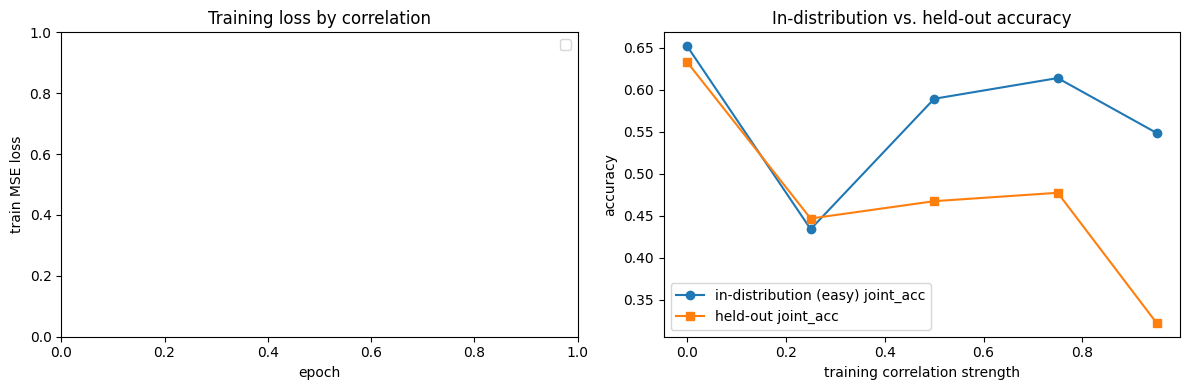



Frechet Factor Distance and memorization-check summary:
  corr=0.0: in_dist_acc=0.652, joint_ffd=137.91, composed_ffd=67.01, nn_dist_min=4.86, final_loss=0.0016
  corr=0.25: in_dist_acc=0.434, joint_ffd=279.79, composed_ffd=570.52, nn_dist_min=3.75, final_loss=0.0014
  corr=0.5: in_dist_acc=0.589, joint_ffd=246.22, composed_ffd=317.05, nn_dist_min=6.10, final_loss=0.0015
  corr=0.75: in_dist_acc=0.614, joint_ffd=246.90, composed_ffd=240.40, nn_dist_min=4.35, final_loss=0.0013
  corr=0.95: in_dist_acc=0.549, joint_ffd=413.18, composed_ffd=866.56, nn_dist_min=4.32, final_loss=0.0012


In [45]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))      
        
for corr, losses in losses_by_correlation.items():
    axes[0].plot(losses, label=f'corr={corr}')
axes[0].set_xlabel('epoch')
axes[0].set_ylabel('train MSE loss')
axes[0].set_title('Training loss by correlation')
axes[0].legend()

corrs = [d['correlation'] for d in diagnostics]
in_dist = [d['in_distribution_joint_acc'] for d in diagnostics]
held_out_means = [np.mean([r['joint_acc'] for r in results if r['correlation'] == c]) for c in corrs]
axes[1].plot(corrs, in_dist, marker='o', label='in-distribution (easy) joint_acc')
axes[1].plot(corrs, held_out_means, marker='s', label='held-out joint_acc')
axes[1].set_xlabel('training correlation strength')
axes[1].set_ylabel('accuracy')
axes[1].set_title('In-distribution vs. held-out accuracy')
axes[1].legend()

plt.tight_layout()
plt.savefig('/kaggle/working/diagnostics_plot.png', dpi=120)
plt.show()

print('\n')
print('Frechet Factor Distance and memorization-check summary:')
for d in diagnostics:
    print(f"  corr={d['correlation']}: in_dist_acc={d['in_distribution_joint_acc']:.3f}, "
          f"joint_ffd={d['joint_ffd']:.2f}, composed_ffd={d['composed_ffd']:.2f}, "
          f"nn_dist_min={d['nn_dist_min']:.2f}, final_loss={d['final_train_loss']:.4f}")


In [46]:
!pip freeze > /kaggle/working/requirements.txt
print('saved /kaggle/working/requirements.txt')

saved /kaggle/working/requirements.txt


In [47]:
all_results = load_json_list(RESULTS_PATH)

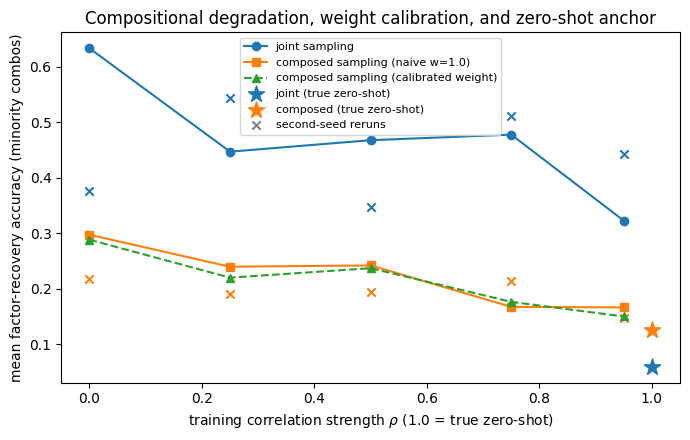


 all figures saved under /kaggle/working/figures/
  composed_zeroshot.png
  dataset_samples.png
  ddim_step_ablation.png
  degradation_curve.png
  entanglement_diagnostic.png
  full_summary_curve.png
  joint_zeroshot.png
  weight_calibration.png


In [48]:
corrs = sorted(set(r['correlation'] for r in all_results))
joint_means = [np.mean([r['joint_acc'] for r in all_results if r['correlation']==c]) for c in corrs]
composed_means = [np.mean([r['composed_acc'] for r in all_results if r['correlation']==c]) for c in corrs]

plt.figure(figsize=(7,4.5))
plt.plot(corrs, joint_means, marker='o', label='joint sampling')
plt.plot(corrs, composed_means, marker='s', label='composed sampling (naive w=1.0)')

if Path('/kaggle/working/weight_calibration.json').exists():
    wc = json.load(open('/kaggle/working/weight_calibration.json'))
    best_by_corr = {}
    for c in corrs:
        rows = [r for r in wc if r['correlation']==c]
        if rows:
            best_by_corr[c] = max(rows, key=lambda r: r['composed_acc'])['composed_acc']
    if best_by_corr:
        plt.plot(list(best_by_corr.keys()), list(best_by_corr.values()), marker='^', linestyle='--', label='composed sampling (calibrated weight)')

if Path('/kaggle/working/zero_shot_results.json').exists():
    zs = json.load(open('/kaggle/working/zero_shot_results.json'))
    zs_joint = np.mean([r['joint_acc'] for r in zs])
    zs_composed = np.mean([r['composed_acc'] for r in zs])
    plt.scatter([1.0], [zs_joint], marker='*', s=150, color='C0', label='joint (true zero-shot)')
    plt.scatter([1.0], [zs_composed], marker='*', s=150, color='C1', label='composed (true zero-shot)')

if Path('/kaggle/working/sweep_results_seed2.json').exists():
    s2 = json.load(open('/kaggle/working/sweep_results_seed2.json'))
    for c in sorted(set(r['correlation'] for r in s2)):
        rows = [r for r in s2 if r['correlation']==c]
        jm = np.mean([r['joint_acc'] for r in rows])
        cm = np.mean([r['composed_acc'] for r in rows])
        plt.scatter([c],[jm], marker='x', color='C0')
        plt.scatter([c],[cm], marker='x', color='C1')
    plt.scatter([],[], marker='x', color='gray', label='second-seed reruns')

plt.xlabel('training correlation strength $\\rho$ (1.0 = true zero-shot)')
plt.ylabel('mean factor-recovery accuracy (minority combos)')
plt.title('Compositional degradation, weight calibration, and zero-shot anchor')
plt.legend(fontsize=8)
plt.tight_layout()
plt.savefig(FIGURES_DIR/'full_summary_curve.png', dpi=150)
plt.show()

print('\n all figures saved under /kaggle/working/figures/')
for f in sorted(FIGURES_DIR.glob('*.png')):
    print(' ', f.name)


Numbers for the report

In [49]:
def binom_ci95(p,n):
    return 1.96*math.sqrt(p*(1-p)/n)

In [50]:
print("Ablation (n=64 per step count)")
for r in ablation_results:
    ci = binom_ci95(r['joint_acc'], 64)
    print(f"steps={r['steps']}: joint_acc={r['joint_acc']:.3f} ± {ci:.3f}")


Ablation (n=64 per step count)
steps=50: joint_acc=0.734 ± 0.108
steps=100: joint_acc=0.859 ± 0.085
steps=200: joint_acc=0.641 ± 0.118
steps=300: joint_acc=0.688 ± 0.114


In [51]:
print("Entanglement (n=256 per shape/ρ)")
for r in entanglement_results:
    p = r['scale_dist'][matchingScaleMap()[r['shape']]]
    ci = binom_ci95(p, 256)
    print(f"corr={r['correlation']}, shape={r['shape']}: matching_scale_prob={p:.3f} ± {ci:.3f}")


Entanglement (n=256 per shape/ρ)
corr=0.0, shape=0: matching_scale_prob=0.348 ± 0.058
corr=0.0, shape=1: matching_scale_prob=0.250 ± 0.053
corr=0.0, shape=2: matching_scale_prob=0.426 ± 0.061
corr=0.25, shape=0: matching_scale_prob=0.633 ± 0.059
corr=0.25, shape=1: matching_scale_prob=0.203 ± 0.049
corr=0.25, shape=2: matching_scale_prob=0.250 ± 0.053
corr=0.5, shape=0: matching_scale_prob=0.645 ± 0.059
corr=0.5, shape=1: matching_scale_prob=0.340 ± 0.058
corr=0.5, shape=2: matching_scale_prob=0.332 ± 0.058
corr=0.75, shape=0: matching_scale_prob=0.688 ± 0.057
corr=0.75, shape=1: matching_scale_prob=0.352 ± 0.058
corr=0.75, shape=2: matching_scale_prob=0.418 ± 0.060
corr=0.95, shape=0: matching_scale_prob=0.824 ± 0.047
corr=0.95, shape=1: matching_scale_prob=0.441 ± 0.061
corr=0.95, shape=2: matching_scale_prob=0.301 ± 0.056


In [52]:
print("Weight calibration (n=3000, aggregated over 6 combosx500)")
for r in weightCalibRes:
    ci = binom_ci95(r['composed_acc'], 3000)
    print(f"corr={r['correlation']}, w={r['weight']}: composed_acc={r['composed_acc']:.3f} ± {ci:.3f}")


Weight calibration (n=3000, aggregated over 6 combosx500)
corr=0.0, w=0.5: composed_acc=0.288 ± 0.016
corr=0.0, w=1.0: composed_acc=0.285 ± 0.016
corr=0.0, w=1.5: composed_acc=0.118 ± 0.012
corr=0.0, w=2.0: composed_acc=0.067 ± 0.009
corr=0.25, w=0.5: composed_acc=0.183 ± 0.014
corr=0.25, w=1.0: composed_acc=0.220 ± 0.015
corr=0.25, w=1.5: composed_acc=0.109 ± 0.011
corr=0.25, w=2.0: composed_acc=0.051 ± 0.008
corr=0.5, w=0.5: composed_acc=0.201 ± 0.014
corr=0.5, w=1.0: composed_acc=0.237 ± 0.015
corr=0.5, w=1.5: composed_acc=0.136 ± 0.012
corr=0.5, w=2.0: composed_acc=0.067 ± 0.009
corr=0.75, w=0.5: composed_acc=0.158 ± 0.013
corr=0.75, w=1.0: composed_acc=0.176 ± 0.014
corr=0.75, w=1.5: composed_acc=0.052 ± 0.008
corr=0.75, w=2.0: composed_acc=0.020 ± 0.005
corr=0.95, w=0.5: composed_acc=0.106 ± 0.011
corr=0.95, w=1.0: composed_acc=0.150 ± 0.013
corr=0.95, w=1.5: composed_acc=0.145 ± 0.013
corr=0.95, w=2.0: composed_acc=0.082 ± 0.010


In [53]:
print("Main degradation sweep (n=3000, aggregated over 6 combosx500)")
for corr in CORRELATIONS:
    rows = [r for r in all_results if r['correlation'] == corr]
    joint_mean = np.mean([r['joint_acc'] for r in rows])
    composed_mean = np.mean([r['composed_acc'] for r in rows])
    print('corr', corr)
    print('joint_mean', joint_mean)
    print('joint_ci95', binom_ci95(joint_mean, 3000))
    print('composed_mean', composed_mean)
    print('composed_ci95', binom_ci95(composed_mean, 3000))

Main degradation sweep (n=3000, aggregated over 6 combosx500)
corr 0.0
joint_mean 0.6330000261465708
joint_ci95 0.017247665647672595
composed_mean 0.29700001950065297
composed_ci95 0.016351264334549833
corr 0.25
joint_mean 0.4466666926940282
joint_ci95 0.017790191987791748
composed_mean 0.23933334400256476
composed_ci95 0.015268424927754253
corr 0.5
joint_mean 0.4673333466053009
joint_ci95 0.017854043326247918
composed_mean 0.2416666770974795
composed_ci95 0.015319122867176075
corr 0.75
joint_mean 0.47733335693677265
joint_ci95 0.017873875492829247
composed_mean 0.16700000626345476
composed_ci95 0.013346770316261082
corr 0.95
joint_mean 0.32233334332704544
joint_ci95 0.016724614617026047
composed_mean 0.16600000827262798
composed_ci95 0.013314734840633329


In [54]:
ciSummary = {
    'ablation': [{**r, 'ci95': binom_ci95(r['joint_acc'], 64)} for r in ablation_results],
    'entanglement': [{**r, 'ci95': binom_ci95(r['scale_dist'][matchingScaleMap()[r['shape']]], 256)} for r in entanglement_results],
}
json.dump(ciSummary, open('/kaggle/working/ci_summary.json', 'w'), indent=2)